Starting best score , % target 65.33333333333333
End best score , % target: 100.0


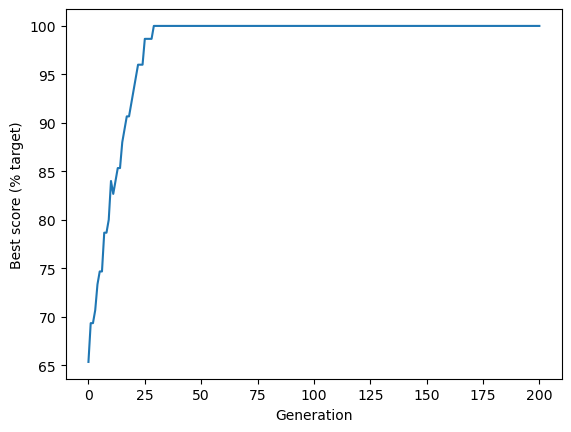

In [1]:
import numpy as np

def create_reference_solution(chromosome_lenght):
    number_of_ones = int(chromosome_lenght / 2)
    #Bulid an array whit an equal mix of zero and ones
    reference = np.zeros(chromosome_lenght)
    reference[0: number_of_ones] = 1
    # Shuffle the array to mix the zeros and ones
    np.random.shuffle(reference)
    return reference


def creat_starting_population(individual , chromosome_lenght):
    # Set up an initial array of all zeros
    population = np.zeros((individual , chromosome_lenght))
    #loop through each row (individual)
    for i in range(individual):
        #choose a random number of ones to creat
        ones = np.random.randint(0 , chromosome_lenght)
        # Change the required number of zero to ones
        population[i , 0:ones] = 1
        #shuffle row
        np.random.shuffle(population[i])
    return population


def calculate_fitness(reference , population ):
    # Creat an array of true/false compared to reference
    indentical_to_reference = population == reference
    # Sum number of genes that are identical to the reference
    fitness_score = indentical_to_reference.sum(axis = 1)
    
    return fitness_score


def select_individual_by_tournament(population , scores):
    # Get population size
    population_size = len(scores)

    # Pick 2 individuals for tournament
    fighter_1 = np.random.randint(0 , population_size-1)
    fighter_2 = np.random.randint(0 , population_size-1)

    # Get fitness score for each 
    fighter_1_fitness = scores[fighter_1]
    fighter_2_fitness = scores[fighter_2]

    # Identify undividual whit highest fitness
    # Fighter 1 will win if score are equal

    if fighter_1_fitness >= fighter_2_fitness:
        winner = fighter_1

    else:
        winner = fighter_2

# Return the chromsome of the winer
    return population[winner , :]


def breed_by_crossover(parent_1 , Parent_2):
    # Get lenght of chromosom
    chromosome_lenght = len(parent_1)

    # Pick crossover point , avoiding  ends of chromsome
    crossover_point = np.random.randint(1 , chromosome_lenght-1)

    # Creat children , np.hstack joins two array 
    child_1 = np.hstack((parent_1[0 : crossover_point] , parent_2[crossover_point:]))
    child_2 = np.hstack((parent_2[0:crossover_point],parent_1[crossover_point:]))
    

    # Return children
    return child_1 , child_2


def randomly_mutate_population(population, mutation_probability):

    # Apply random mutation
    random_mutation_array = np.random.random(size=(population.shape))

    random_mutation_boolean = random_mutation_array <= mutation_probability

    # Apply mutation by flipping the bits
    population[random_mutation_boolean] = np.logical_not(population[random_mutation_boolean])


    #Return mutation population
    return population



# *************** Main Algoritm Code **************************

# set general parameters

chromosome_lenght = 75
population_size = 500
maximum_generation = 200
best_score_progress = [] # Track progress

# Creat reference solution
# (this is used just to illustrate GAs)
reference = create_reference_solution(chromosome_lenght)

# Creat starting population
population = creat_starting_population(population_size , chromosome_lenght)

# Display best score in starting population
scores = calculate_fitness(reference , population)
best_score = np.max(scores) / chromosome_lenght * 100
print("Starting best score , % target" , best_score)

# Add starting best score to progress tracker
best_score_progress.append(best_score)

# Now we'll go through the generations of genetic algoritm
for generation in range(maximum_generation):
    # Creat an empty list for new population
    new_population = []

    #Creat new population generation two children at a time
    for i in range(int(population_size/2)):
        parent_1 = select_individual_by_tournament(population , scores)
        parent_2 = select_individual_by_tournament(population , scores)
        child_1 , child_2 = breed_by_crossover(parent_1 , parent_2)
        new_population.append(child_1)
        new_population.append(child_2)

    # Replace the old population with the new one
    population = np.array(new_population)

    # Apply mutation
    mutation_rate = 0.002
    population = randomly_mutate_population(population , mutation_rate)

    # Score best solution , and add to tracker
    scores = calculate_fitness(reference , population)
    best_score = np.max(scores) / chromosome_lenght * 100
    best_score_progress.append(best_score)

# GA has completed required generation
print("End best score , % target:" , best_score)


#plot progress
import matplotlib.pyplot as plt
plt.plot(best_score_progress)
plt.xlabel('Generation')
plt.ylabel('Best score (% target)')
plt.show()